# Multiclase NHANES

## Preparación de datos

In [2]:
# Conectar Google Drive
from google.colab import drive
drive.mount("/content/gdrive")

Mounted at /content/gdrive


In [10]:
import os
import pandas as pd
import numpy as np

path = '/content/gdrive/MyDrive/SIS420/datasets/dataset_labs/NHANES/'
print("Archivos en carpeta:")
print(os.listdir(path))

Archivos en carpeta:
['DEMO_L.xpt', 'BMX_L.xpt', 'GHB_L.xpt', 'HDL_L.xpt', 'ALQ_L.xpt', 'SLQ_L.xpt', 'SMQ_L.xpt', 'BPQ_L.xpt', 'MCQ_L.xpt']


In [29]:
# Multiclase NHANES — Riesgo Cardíaco con PyTorch

# ── Cargar datasets ────────────────────────────────────────────────────────
demo  = pd.read_sas(path + 'DEMO_L.xpt',  format='xport', encoding='utf-8')
bmx   = pd.read_sas(path + 'BMX_L.xpt',   format='xport', encoding='utf-8')
ghb   = pd.read_sas(path + 'GHB_L.xpt',   format='xport', encoding='utf-8')
hdl   = pd.read_sas(path + 'HDL_L.xpt',   format='xport', encoding='utf-8')
alq   = pd.read_sas(path + 'ALQ_L.xpt',   format='xport', encoding='utf-8')
slq   = pd.read_sas(path + 'SLQ_L.xpt',   format='xport', encoding='utf-8')
mcq   = pd.read_sas(path + 'MCQ_L.xpt',   format='xport', encoding='utf-8')
bpq   = pd.read_sas(path + 'BPQ_L.xpt',   format='xport', encoding='utf-8')
smq   = pd.read_sas(path + 'SMQ_L.xpt',   format='xport', encoding='utf-8')
# NUEVOS: colesterol total, presión arterial oscilométrica, actividad física, diabetes
tchol = pd.read_sas(path + 'TCHOL_L.xpt', format='xport', encoding='utf-8')
bpxo  = pd.read_sas(path + 'BPXO_L.xpt',  format='xport', encoding='utf-8')
paq   = pd.read_sas(path + 'PAQ_L.xpt',   format='xport', encoding='utf-8')
diq   = pd.read_sas(path + 'DIQ_L.xpt',   format='xport', encoding='utf-8')

print("Todos los archivos cargados")

Todos los archivos cargados


In [30]:
# ── Variable objetivo: evento cardíaco diagnosticado por médico ────────────
# MCQ160E = infarto al corazón (myocardial infarction)
# MCQ160B = insuficiencia cardíaca congestiva (heart failure)
# MCQ160C = angina / enfermedad coronaria
# MCQ160D = angina de pecho (overlaps con 160C, se incluye)
# Valores NHANES: 1=Sí, 2=No, 7=No sabe, 9=Rehúsa, NaN=No aplica

cols_evento = ['MCQ160E', 'MCQ160B', 'MCQ160C', 'MCQ160D']
mcq_sel = mcq[['SEQN'] + cols_evento].copy()

for col in cols_evento:
    mcq_sel[col] = mcq_sel[col].apply(lambda x: 1 if x == 1.0 else 0)

# Clasificación multiclase (basada en severidad clínica):
# Clase 0 — Sin evento cardíaco registrado
# Clase 1 — Riesgo moderado: angina / enfermedad coronaria sin infarto ni fallo
# Clase 2 — Riesgo alto: infarto o insuficiencia cardíaca (eventos graves)
def clasificar_evento(row):
    if row['MCQ160E'] == 1 or row['MCQ160B'] == 1:
        return 2  # grave: infarto o insuficiencia cardíaca
    elif row['MCQ160C'] == 1 or row['MCQ160D'] == 1:
        return 1  # moderado: angina / coronaria
    else:
        return 0  # sin evento

mcq_sel['evento_cardiaco'] = mcq_sel.apply(clasificar_evento, axis=1)

counts = mcq_sel['evento_cardiaco'].value_counts().sort_index()
labels_clase = {0: 'Bajo riesgo (0)', 1: 'Moderado — Angina (1)', 2: 'Alto — Infarto/Insuf. (2)'}
print("Distribución de clases (variable objetivo CDC):")
for k, v in counts.items():
    print(f"  {labels_clase[k]}: {v} ({100*v/len(mcq_sel):.1f}%)")

Distribución de clases (variable objetivo CDC):
  Bajo riesgo (0): 10999 (93.7%)
  Moderado — Angina (1): 207 (1.8%)
  Alto — Infarto/Insuf. (2): 538 (4.6%)


In [33]:
# Merge completo de todos los datasets

import matplotlib.pyplot as plt

# ── Selección de variables por dataset ────────────────────────────────────
demo_sel  = demo[['SEQN', 'RIDAGEYR', 'RIAGENDR', 'DMDEDUC2']].copy()
bmx_sel   = bmx[['SEQN', 'BMXBMI', 'BMXWAIST']].copy()       # BMI + cintura
ghb_sel   = ghb[['SEQN', 'LBXGH']].copy()                    # HbA1c
hdl_sel   = hdl[['SEQN', 'LBDHDD']].copy()                   # HDL
tchol_sel = tchol[['SEQN', 'LBXTC']].copy()                  # Colesterol total
bpxo_sel  = bpxo[['SEQN', 'BPXOSY3']].copy()                 # Presión sistólica
alq_sel   = alq[['SEQN', 'ALQ111', 'ALQ121', 'ALQ130']].copy()
slq_sel   = slq[['SEQN', 'SLD012']].copy()                   # Horas de sueño
bpq_sel   = bpq[['SEQN', 'BPQ020']].copy()                   # Hipertensión Dx
smq_sel   = smq[['SEQN', 'SMQ020']].copy()                   # Fumador

# Actividad física continua (PAD800 + PAD820)
paq_sel = paq[['SEQN', 'PAD800', 'PAD820']].copy()
paq_sel['act_fisica_total'] = paq_sel[['PAD800', 'PAD820']].fillna(0).sum(axis=1)
paq_sel = paq_sel[['SEQN', 'act_fisica_total']]

diq_sel   = diq[['SEQN', 'DIQ010']].copy()                   # Diabetes Dx
mcq_sel2  = mcq_sel[['SEQN', 'evento_cardiaco']].copy()

# ── Merge progresivo ──────────────────────────────────────────────────────
df = demo_sel.copy()
for tabla in [bmx_sel, ghb_sel, hdl_sel, tchol_sel, bpxo_sel,
              alq_sel, slq_sel, bpq_sel, smq_sel, paq_sel, diq_sel, mcq_sel2]:
    df = df.merge(tabla, on='SEQN', how='left')

# ── Renombrar columnas ────────────────────────────────────────────────────
df.rename(columns={
    'RIDAGEYR': 'edad',     'RIAGENDR': 'sexo',      'DMDEDUC2': 'educacion',
    'BMXBMI':   'bmi',      'BMXWAIST': 'cintura',
    'LBXGH':    'hba1c',    'LBDHDD':   'hdl',        'LBXTC':    'col_total',
    'BPXOSY3':  'presion_sistolica',
    'SLD012':   'sueno',    'BPQ020':   'hipertension',
    'SMQ020':   'fumador',  'DIQ010':   'diabetes'
}, inplace=True)

print(f"Shape tras merge: {df.shape}")

# ── Limpieza ──────────────────────────────────────────────────────────────
def limpiar_codigos(serie, codigos=[7, 9, 77, 99, 777, 999, 7777, 9999]):
    return serie.replace(codigos, np.nan)

for col in ['ALQ111', 'ALQ121', 'ALQ130', 'sueno', 'educacion',
            'presion_sistolica', 'cintura', 'col_total']:
    df[col] = limpiar_codigos(df[col])

# ── Consolidar alcohol (bebidas/semana) ───────────────────────────────────
def consolidar_alcohol(row):
    if row['ALQ111'] == 2:
        return 0.0
    if pd.notna(row['ALQ121']) and pd.notna(row['ALQ130']):
        return round((row['ALQ121'] / 52.0) * row['ALQ130'], 2)
    if pd.notna(row['ALQ130']):
        return row['ALQ130']
    return np.nan

df['alcohol'] = df.apply(consolidar_alcohol, axis=1)
df.drop(columns=['ALQ111', 'ALQ121', 'ALQ130'], inplace=True)

# ── Variables binarias ────────────────────────────────────────────────────
for col in ['hipertension', 'fumador', 'diabetes']:
    df[col] = df[col].apply(lambda x: 1 if x == 1.0 else (0 if x == 2.0 else np.nan))

# 🔥 Actividad física (ya es continua, NO binarizar)
df.rename(columns={'act_fisica_total': 'act_fisica'}, inplace=True)

# Educación
df['educacion'] = df['educacion'].apply(lambda x: x if x in [1,2,3,4,5] else np.nan)

# ── Nulos ─────────────────────────────────────────────────────────────────
print("\nNulos por columna:")
nulos = df.isnull().sum()
print(nulos[nulos > 0].sort_values(ascending=False))

Shape tras merge: (11933, 19)

Nulos por columna:
alcohol              7356
sueno                5753
hba1c                5218
col_total            5050
hdl                  5043
presion_sistolica    4573
educacion            4150
fumador              3812
cintura              3791
act_fisica           3780
bmi                  3462
hipertension         3446
diabetes              481
evento_cardiaco       189
dtype: int64


In [14]:
# Limpieza y consolidación de alcohol

# Filtrar valores especiales NHANES (7=no sabe, 9=rehúsa, 77/99/777/999 similares)
def limpiar_codigos(serie, codigos=[7, 9, 77, 99, 777, 999, 7777, 9999]):
    return serie.replace(codigos, np.nan)

df['ALQ111'] = limpiar_codigos(df['ALQ111'])
df['ALQ121'] = limpiar_codigos(df['ALQ121'])
df['ALQ130'] = limpiar_codigos(df['ALQ130'])
df['sueno']  = limpiar_codigos(df['sueno'])

# Consolidar alcohol: bebidas por semana en promedio
def consolidar_alcohol(row):
    if row['ALQ111'] == 2:        # respondió que NO toma
        return 0.0
    if pd.notna(row['ALQ121']) and pd.notna(row['ALQ130']):
        dias_semana = row['ALQ121'] / 52.0
        return round(dias_semana * row['ALQ130'], 2)
    if pd.notna(row['ALQ130']):
        return row['ALQ130']
    return np.nan

df['alcohol'] = df.apply(consolidar_alcohol, axis=1)
df.drop(columns=['ALQ111','ALQ121','ALQ130'], inplace=True)

# Hipertensión y fumador: convertir 2→0 (no), dejar 1 como 1 (sí)
df['hipertension'] = df['hipertension'].apply(
    lambda x: 1 if x == 1.0 else (0 if x == 2.0 else np.nan))
df['fumador'] = df['fumador'].apply(
    lambda x: 1 if x == 1.0 else (0 if x == 2.0 else np.nan))

print("Nulos tras limpieza:")
print(df.isnull().sum()[df.isnull().sum() > 0].sort_values(ascending=False))

Nulos tras limpieza:
alcohol            7356
sueno              5753
hba1c              5218
hdl                5043
fumador            3812
bmi                3462
hipertension       3446
evento_cardiaco     189
dtype: int64


Filas con variable objetivo: 11744
Nulos en features antes de imputar:
edad                    0
sexo                    0
educacion            3961
bmi                  3273
cintura              3602
hba1c                5029
hdl                  4854
col_total            4861
presion_sistolica    4384
alcohol              7167
sueno                5564
hipertension         3257
fumador              3623
diabetes              292
act_fisica           3591
dtype: int64

Filas finales: 11744
Nulos tras imputar: 0


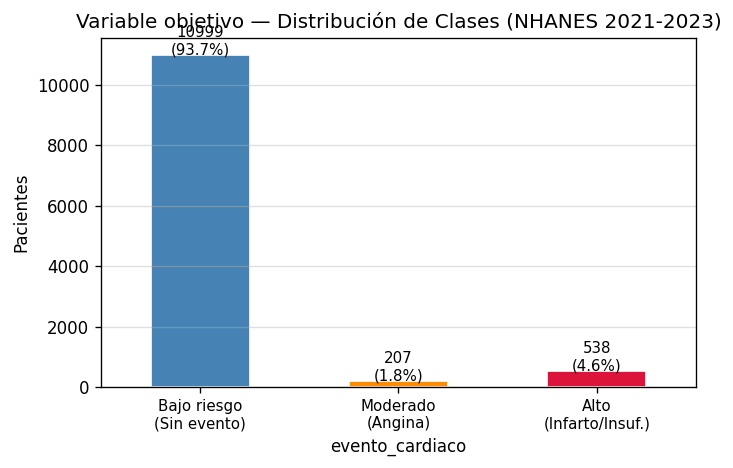

In [34]:
from sklearn.impute import KNNImputer

features = [
    'edad', 'sexo', 'educacion',
    'bmi', 'cintura',
    'hba1c', 'hdl', 'col_total', 'presion_sistolica',
    'alcohol', 'sueno',
    'hipertension', 'fumador', 'diabetes', 'act_fisica'
]

df_model = df[features + ['evento_cardiaco']].copy()
df_model = df_model.dropna(subset=['evento_cardiaco'])

print(f"Filas con variable objetivo: {len(df_model)}")
print("Nulos en features antes de imputar:")
print(df_model[features].isnull().sum())

imputer = KNNImputer(n_neighbors=5)
X_imp = imputer.fit_transform(df_model[features])
df_imp = pd.DataFrame(X_imp, columns=features)
df_imp['evento_cardiaco'] = df_model['evento_cardiaco'].values

print(f"\nFilas finales: {len(df_imp)}")
print("Nulos tras imputar:", df_imp.isnull().sum().sum())

# ── Distribución de clases ────────────────────────────────────────────────
counts = df_imp['evento_cardiaco'].value_counts().sort_index()
labels_str = ['Bajo riesgo\n(Sin evento)', 'Moderado\n(Angina)', 'Alto\n(Infarto/Insuf.)']
colors_cls = ['steelblue', 'darkorange', 'crimson']

fig, ax = plt.subplots(figsize=(6, 4), dpi=120)
counts.plot(kind='bar', ax=ax, color=colors_cls, edgecolor='white')
ax.set_xticklabels(labels_str, rotation=0, fontsize=9)
ax.set_ylabel('Pacientes')
ax.set_title('Variable objetivo — Distribución de Clases (NHANES 2021-2023)')
ax.grid(axis='y', alpha=0.4)
for i, v in enumerate(counts):
    ax.text(i, v + 5, f'{v}\n({100*v/len(df_imp):.1f}%)', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## Dataset, DataLoader y normalización

In [35]:
import torch
from torch.utils.data import DataLoader, TensorDataset

X_all = df_imp[features].values.astype(np.float32)
y_all = df_imp['evento_cardiaco'].values.astype(np.int64)

# Normalización min-max
X_min = X_all.min(axis=0)
X_max = X_all.max(axis=0)
X_norm = (X_all - X_min) / (X_max - X_min + 1e-8)

np.random.seed(42)
idx     = np.random.permutation(len(X_norm))
n_train = int(len(idx) * 0.70)
n_val   = int(len(idx) * 0.15)

X_train = X_norm[idx[:n_train]];              y_train = y_all[idx[:n_train]]
X_val   = X_norm[idx[n_train:n_train+n_val]]; y_val   = y_all[idx[n_train:n_train+n_val]]
X_test  = X_norm[idx[n_train+n_val:]];        y_test  = y_all[idx[n_train+n_val:]]

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

class NHANESDataset(torch.utils.data.Dataset):
    def __init__(self, X, Y):
        self.X = torch.from_numpy(X).float()
        self.Y = torch.from_numpy(Y).long()
    def __len__(self):
        return len(self.X)
    def __getitem__(self, ix):
        return self.X[ix], self.Y[ix]

dataset = {
    'train': NHANESDataset(X_train, y_train),
    'val':   NHANESDataset(X_val,   y_val),
}
dataloader = {
    'train': DataLoader(dataset['train'], batch_size=64, shuffle=True),
    'val':   DataLoader(dataset['val'],   batch_size=512, shuffle=False),
}

D_IN = len(features)  # 15 features ahora
print(f"Dimensión de entrada: {D_IN}")

Train: 8220 | Val: 1761 | Test: 1763
Dimensión de entrada: 15


## Modelo MLP y función fit con regularización

In [36]:
from sklearn.metrics import accuracy_score

def softmax(x):
    return torch.exp(x) / torch.exp(x).sum(axis=-1, keepdims=True)

def build_model(D_in=D_IN, H=128, D_out=3, p=0.0):
    """MLP con 3 capas ocultas. H más grande para 15 features."""
    return torch.nn.Sequential(
        torch.nn.Linear(D_in, H),
        torch.nn.BatchNorm1d(H),
        torch.nn.ReLU(),
        torch.nn.Dropout(p),
        torch.nn.Linear(H, H // 2),
        torch.nn.BatchNorm1d(H // 2),
        torch.nn.ReLU(),
        torch.nn.Dropout(p),
        torch.nn.Linear(H // 2, D_out)
    )

def fit(model, dataloader, epochs=300, log_each=20,
        weight_decay=0, early_stopping=0, lr=1e-3):
    """
    Entrena el modelo y devuelve historial.
    Usa Adam (más estable que SGD para este dataset).
    Imprime accuracy de train Y val en cada log.
    """
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr,
                                 weight_decay=weight_decay)
    l, acc, val_l, val_acc = [], [], [], []
    best_val_acc, step = 0, 0

    for e in range(1, epochs + 1):
        # ── Train ──
        model.train()
        _l, _acc = [], []
        for x_b, y_b in dataloader['train']:
            y_pred = model(x_b)
            loss   = criterion(y_pred, y_b)
            _l.append(loss.item())
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            preds = torch.argmax(softmax(y_pred), axis=1)
            _acc.append(accuracy_score(y_b.numpy(), preds.detach().numpy()))
        l.append(np.mean(_l))
        acc.append(np.mean(_acc))

        # ── Val ──
        model.eval()
        _l, _acc = [], []
        with torch.no_grad():
            for x_b, y_b in dataloader['val']:
                y_pred = model(x_b)
                loss   = criterion(y_pred, y_b)
                _l.append(loss.item())
                preds  = torch.argmax(softmax(y_pred), axis=1)
                _acc.append(accuracy_score(y_b.numpy(), preds.numpy()))
        val_l.append(np.mean(_l))
        val_acc.append(np.mean(_acc))

        # Checkpoint del mejor modelo
        if val_acc[-1] > best_val_acc:
            best_val_acc = val_acc[-1]
            torch.save(model.state_dict(), 'ckpt.pt')
            step = 0

        step += 1
        if early_stopping and step > early_stopping:
            print(f"  ✗ Early stopping en epoch {e} "
                  f"(sin mejora en {early_stopping} epochs)")
            break

        if not e % log_each:
            print(f"Epoch {e:>4}/{epochs} | "
                  f"loss {l[-1]:.4f}  train_acc {acc[-1]:.4f} | "
                  f"val_loss {val_l[-1]:.4f}  val_acc {val_acc[-1]:.4f}")

    model.load_state_dict(torch.load('ckpt.pt'))
    print(f"\n  ✓ Mejor val_acc: {best_val_acc:.5f}")
    return {'epoch': list(range(1, len(l) + 1)),
            'loss': l, 'acc': acc,
            'val_loss': val_l, 'val_acc': val_acc}

def plot_hist(hist, title):
    fig = plt.figure(dpi=130, figsize=(11, 3.5))
    ax = plt.subplot(121)
    pd.DataFrame(hist).plot(x='epoch', y=['loss', 'val_loss'], grid=True, ax=ax)
    ax.set_title("Loss"); ax.set_xlabel("Epoch")
    ax = plt.subplot(122)
    pd.DataFrame(hist).plot(x='epoch', y=['acc', 'val_acc'], grid=True, ax=ax)
    ax.set_title("Accuracy (Train vs Val)"); ax.set_xlabel("Epoch")
    plt.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.show()

def eval_split(model, X, y, split_name="Test"):
    """Calcula accuracy sobre cualquier split (train/val/test)."""
    model.eval()
    with torch.no_grad():
        logits = model(torch.from_numpy(X).float())
        preds  = torch.argmax(softmax(logits), axis=1).numpy()
    acc = accuracy_score(y, preds)
    print(f"  Accuracy {split_name}: {acc:.4f} ({acc*100:.2f}%)")
    return acc, preds

## Experimento 1 — Sin regularización (baseline)

EXPERIMENTO 1: Sin regularización (baseline)
Epoch   30/300 | loss 0.1483  train_acc 0.9455 | val_loss 0.2488  val_acc 0.9227
Epoch   60/300 | loss 0.0993  train_acc 0.9608 | val_loss 0.3592  val_acc 0.9240
Epoch   90/300 | loss 0.0658  train_acc 0.9743 | val_loss 0.4583  val_acc 0.9151
Epoch  120/300 | loss 0.0490  train_acc 0.9827 | val_loss 0.5375  val_acc 0.9061
Epoch  150/300 | loss 0.0406  train_acc 0.9851 | val_loss 0.5665  val_acc 0.9076
Epoch  180/300 | loss 0.0361  train_acc 0.9864 | val_loss 0.6322  val_acc 0.9068
Epoch  210/300 | loss 0.0332  train_acc 0.9890 | val_loss 0.7100  val_acc 0.9039
Epoch  240/300 | loss 0.0267  train_acc 0.9908 | val_loss 0.7346  val_acc 0.8972
Epoch  270/300 | loss 0.0259  train_acc 0.9902 | val_loss 0.7780  val_acc 0.9010
Epoch  300/300 | loss 0.0169  train_acc 0.9939 | val_loss 0.8452  val_acc 0.9096

  ✓ Mejor val_acc: 0.92900


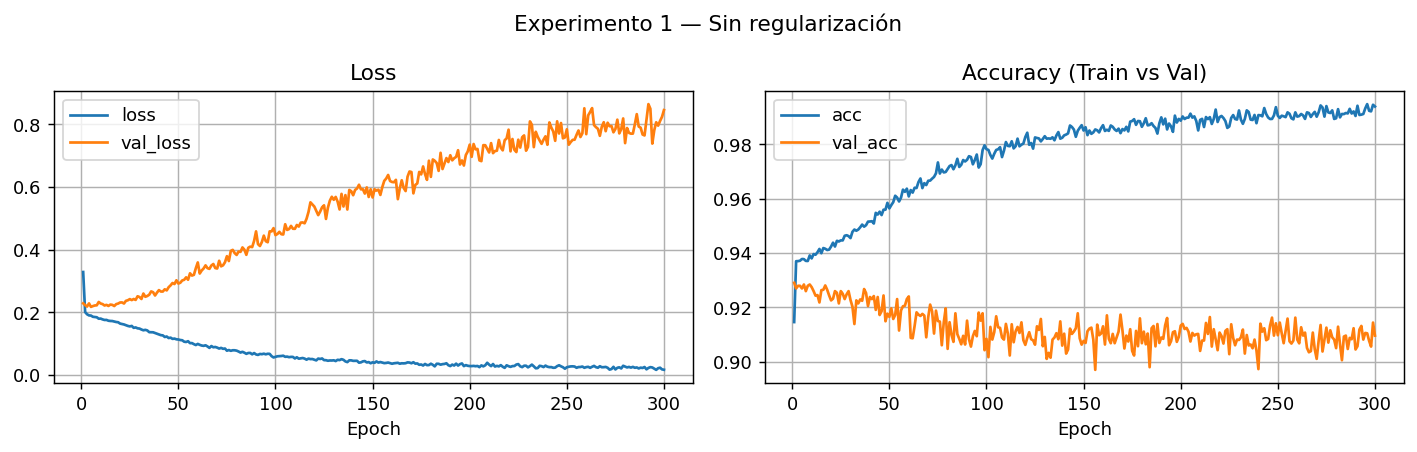


Comparación Train / Val / Test:
  Accuracy Train: 0.9359 (93.59%)
  Accuracy Val  : 0.9290 (92.90%)
  Accuracy Test : 0.9348 (93.48%)


(0.9347702779353375, array([0, 0, 0, ..., 0, 0, 0]))

In [37]:
# ════════════════════════════════════════════════════════════
# EXPERIMENTO 1 — Sin regularización (baseline)
# ════════════════════════════════════════════════════════════
print("=" * 55)
print("EXPERIMENTO 1: Sin regularización (baseline)")
print("=" * 55)
model_base = build_model(p=0.0)
hist_base  = fit(model_base, dataloader, epochs=300, log_each=30, lr=1e-3)
plot_hist(hist_base, "Experimento 1 — Sin regularización")

print("\nComparación Train / Val / Test:")
eval_split(model_base, X_train, y_train, "Train")
eval_split(model_base, X_val,   y_val,   "Val  ")
eval_split(model_base, X_test,  y_test,  "Test ")

## Experimento 2 — Regularización L2

EXPERIMENTO 2: Regularización L2 (weight_decay=0.01)
Epoch   30/300 | loss 0.1976  train_acc 0.9372 | val_loss 0.2168  val_acc 0.9274
Epoch   60/300 | loss 0.1948  train_acc 0.9374 | val_loss 0.2233  val_acc 0.9274
Epoch   90/300 | loss 0.1967  train_acc 0.9377 | val_loss 0.2232  val_acc 0.9274
Epoch  120/300 | loss 0.1952  train_acc 0.9377 | val_loss 0.2164  val_acc 0.9274
Epoch  150/300 | loss 0.1922  train_acc 0.9380 | val_loss 0.2185  val_acc 0.9279
Epoch  180/300 | loss 0.1942  train_acc 0.9377 | val_loss 0.2158  val_acc 0.9279
Epoch  210/300 | loss 0.1942  train_acc 0.9377 | val_loss 0.2177  val_acc 0.9279
Epoch  240/300 | loss 0.1935  train_acc 0.9375 | val_loss 0.2183  val_acc 0.9274
Epoch  270/300 | loss 0.1923  train_acc 0.9377 | val_loss 0.2151  val_acc 0.9274
Epoch  300/300 | loss 0.1941  train_acc 0.9379 | val_loss 0.2214  val_acc 0.9279

  ✓ Mejor val_acc: 0.92789


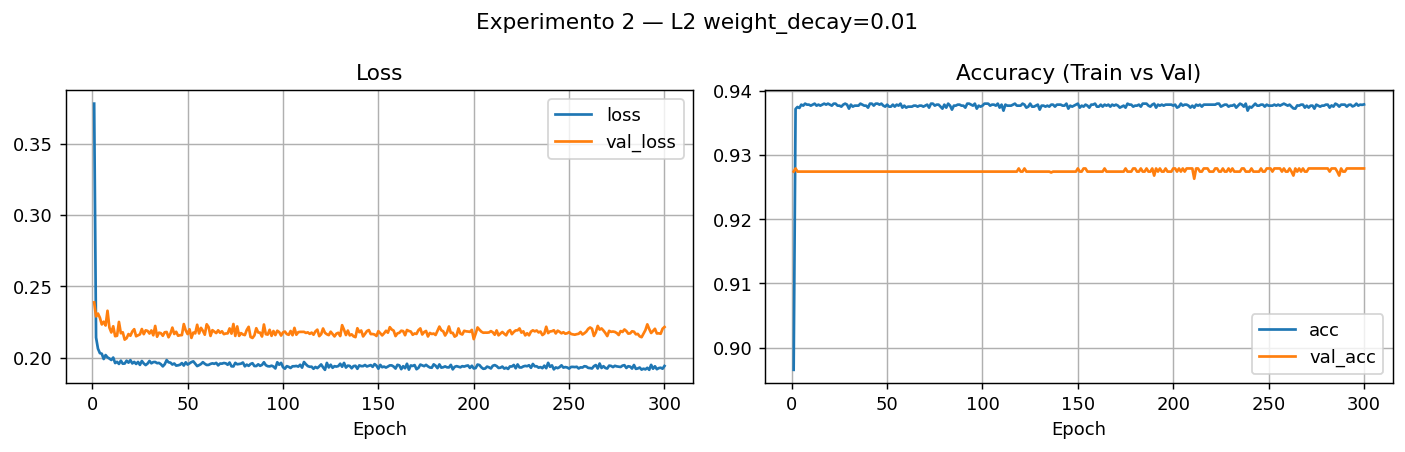


Comparación Train / Val / Test:
  Accuracy Train: 0.9378 (93.78%)
  Accuracy Val  : 0.9284 (92.84%)
  Accuracy Test : 0.9376 (93.76%)


(0.9376063528077141, array([0, 0, 0, ..., 0, 0, 0]))

In [38]:
# ════════════════════════════════════════════════════════════
# EXPERIMENTO 2 — Regularización L2 (weight_decay)
# ════════════════════════════════════════════════════════════
print("=" * 55)
print("EXPERIMENTO 2: Regularización L2 (weight_decay=0.01)")
print("=" * 55)
model_l2 = build_model(p=0.0)
hist_l2  = fit(model_l2, dataloader, epochs=300, log_each=30,
               weight_decay=0.01, lr=1e-3)
plot_hist(hist_l2, "Experimento 2 — L2 weight_decay=0.01")

print("\nComparación Train / Val / Test:")
eval_split(model_l2, X_train, y_train, "Train")
eval_split(model_l2, X_val,   y_val,   "Val  ")
eval_split(model_l2, X_test,  y_test,  "Test ")

## Experimento 3 — Early Stopping

EXPERIMENTO 3: Early Stopping (patience=20)
Epoch   30/300 | loss 0.1504  train_acc 0.9447 | val_loss 0.2429  val_acc 0.9254
  ✗ Early stopping en epoch 36 (sin mejora en 20 epochs)

  ✓ Mejor val_acc: 0.92900


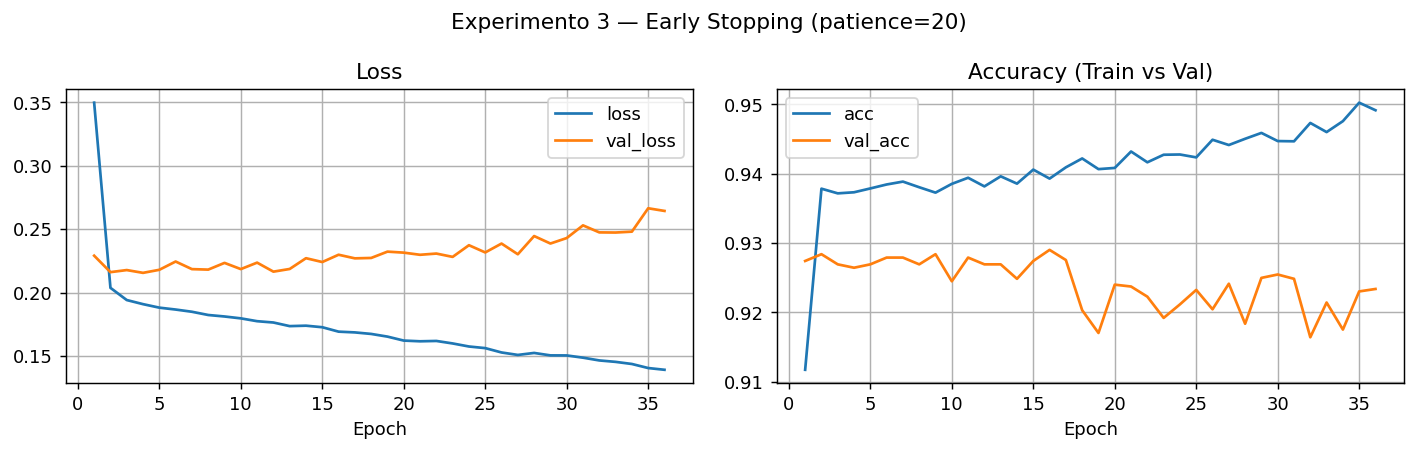


Comparación Train / Val / Test:
  Accuracy Train: 0.9404 (94.04%)
  Accuracy Val  : 0.9290 (92.90%)
  Accuracy Test : 0.9359 (93.59%)

  Brecha Train-Test: 0.45 pp
  Brecha Train-Val:  1.14 pp


In [42]:
# ════════════════════════════════════════════════════════════
# EXPERIMENTO 3 — Early Stopping (sin regularización)
# ════════════════════════════════════════════════════════════
print("=" * 55)
print("EXPERIMENTO 3: Early Stopping (patience=20)")
print("=" * 55)

model_es = build_model(p=0.0)

hist_es  = fit(
    model_es,
    dataloader,
    epochs=300,
    log_each=30,
    early_stopping=20,
    lr=1e-3
)

plot_hist(hist_es, "Experimento 3 — Early Stopping (patience=20)")

print("\nComparación Train / Val / Test:")
acc_train_es, _ = eval_split(model_es, X_train, y_train, "Train")
acc_val_es,   _ = eval_split(model_es, X_val,   y_val,   "Val  ")
acc_test_es,  _ = eval_split(model_es, X_test,  y_test,  "Test ")

print(f"\n  Brecha Train-Test: {(acc_train_es - acc_test_es)*100:.2f} pp")
print(f"  Brecha Train-Val:  {(acc_train_es - acc_val_es)*100:.2f} pp")

## EXPERIMENTO 4 — Dropout + Early Stopping

EXPERIMENTO 3: Dropout(p=0.3) + Early Stopping
Epoch   30/400 | loss 0.1830  train_acc 0.9378 | val_loss 0.2170  val_acc 0.9274
  ✗ Early stopping en epoch 31 (sin mejora en 30 epochs)

  ✓ Mejor val_acc: 0.92949


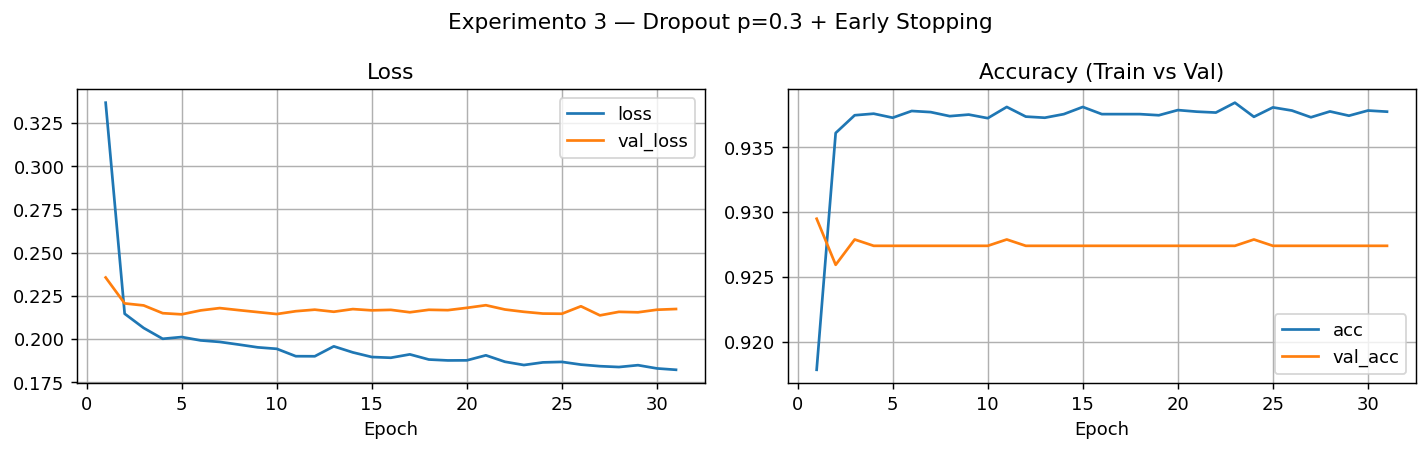


Comparación Train / Val / Test:
  Accuracy Train: 0.9364 (93.64%)
  Accuracy Val  : 0.9296 (92.96%)
  Accuracy Test : 0.9370 (93.70%)

  Brecha Train-Test:  -0.07 pp
  Brecha Train-Val:   0.68 pp
  (brecha < 3pp → buena generalización)


In [39]:
# ════════════════════════════════════════════════════════════
# EXPERIMENTO 4 — Dropout + Early Stopping
# ════════════════════════════════════════════════════════════
print("=" * 55)
print("EXPERIMENTO 3: Dropout(p=0.3) + Early Stopping")
print("=" * 55)
model_dp = build_model(p=0.3)
hist_dp  = fit(model_dp, dataloader, epochs=400, log_each=30,
               early_stopping=30, lr=1e-3)
plot_hist(hist_dp, "Experimento 3 — Dropout p=0.3 + Early Stopping")

print("\nComparación Train / Val / Test:")
acc_train, _ = eval_split(model_dp, X_train, y_train, "Train")
acc_val,   _ = eval_split(model_dp, X_val,   y_val,   "Val  ")
acc_test,  _ = eval_split(model_dp, X_test,  y_test,  "Test ")

# ── Brecha de generalización ──────────────────────────────────
print(f"\n  Brecha Train-Test:  {(acc_train - acc_test)*100:.2f} pp")
print(f"  Brecha Train-Val:   {(acc_train - acc_val)*100:.2f} pp")
print("  (brecha < 3pp → buena generalización)")

## Métricas completas en Test

MÉTRICAS EN TEST — Riesgo Cardíaco (Dropout + ES)

Accuracy:          0.9370
F1-Score macro:    0.3392
F1-Score weighted: 0.9115
ROC-AUC (ovr):     0.8465

Reporte completo por clase:
                       precision    recall  f1-score   support

          Bajo riesgo       0.94      1.00      0.97      1657
    Moderado (Angina)       0.00      0.00      0.00        36
Alto (Infarto/Insuf.)       0.20      0.03      0.05        70

             accuracy                           0.94      1763
            macro avg       0.38      0.34      0.34      1763
         weighted avg       0.89      0.94      0.91      1763



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


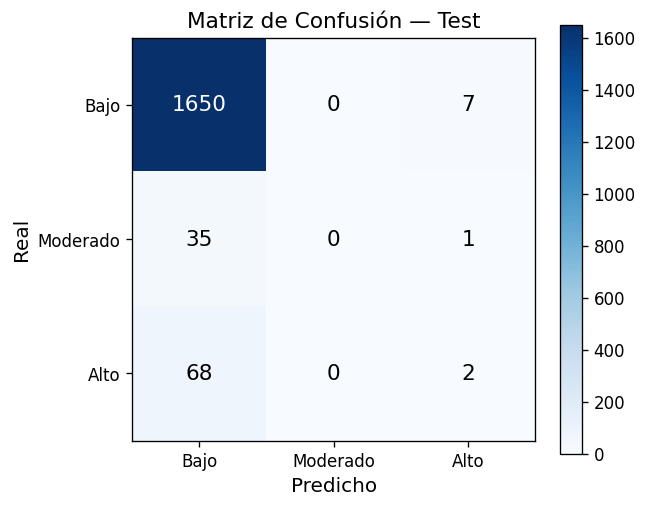

In [40]:
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              precision_score, recall_score,
                              f1_score, roc_auc_score,
                              classification_report)
from sklearn.preprocessing import label_binarize

classes    = ['Bajo riesgo', 'Moderado (Angina)', 'Alto (Infarto/Insuf.)']
colors_cls = ['steelblue', 'darkorange', 'crimson']

# Evaluación en test con el mejor modelo (Experimento 3)
model_dp.eval()
X_test_t = torch.from_numpy(X_test).float()
with torch.no_grad():
    logits  = model_dp(X_test_t)
    y_pred  = torch.argmax(softmax(logits), axis=1).numpy()
    y_proba = softmax(logits).numpy()

print("=" * 55)
print("MÉTRICAS EN TEST — Riesgo Cardíaco (Dropout + ES)")
print("=" * 55)
print(f"\nAccuracy:          {accuracy_score(y_test, y_pred):.4f}")
print(f"F1-Score macro:    {f1_score(y_test, y_pred, average='macro'):.4f}")
print(f"F1-Score weighted: {f1_score(y_test, y_pred, average='weighted'):.4f}")
print(f"ROC-AUC (ovr):     {roc_auc_score(y_test, y_proba, multi_class='ovr'):.4f}")

print("\nReporte completo por clase:")
print(classification_report(y_test, y_pred, target_names=classes))

# ── Matriz de confusión ───────────────────────────────────────────────────
CM = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5.5, 4.5), dpi=120)
im = ax.imshow(CM, cmap='Blues')
ax.set_xticks([0, 1, 2]); ax.set_yticks([0, 1, 2])
ax.set_xticklabels(['Bajo', 'Moderado', 'Alto'], fontsize=10)
ax.set_yticklabels(['Bajo', 'Moderado', 'Alto'], fontsize=10)
ax.set_xlabel('Predicho', fontsize=12)
ax.set_ylabel('Real', fontsize=12)
ax.set_title('Matriz de Confusión — Test', fontsize=13)
for i in range(3):
    for j in range(3):
        ax.text(j, i, CM[i, j], ha='center', va='center',
                fontsize=13, color='white' if CM[i, j] > CM.max() * 0.5 else 'black')
plt.colorbar(im)
plt.tight_layout()
plt.show()

## Curvas ROC multiclase

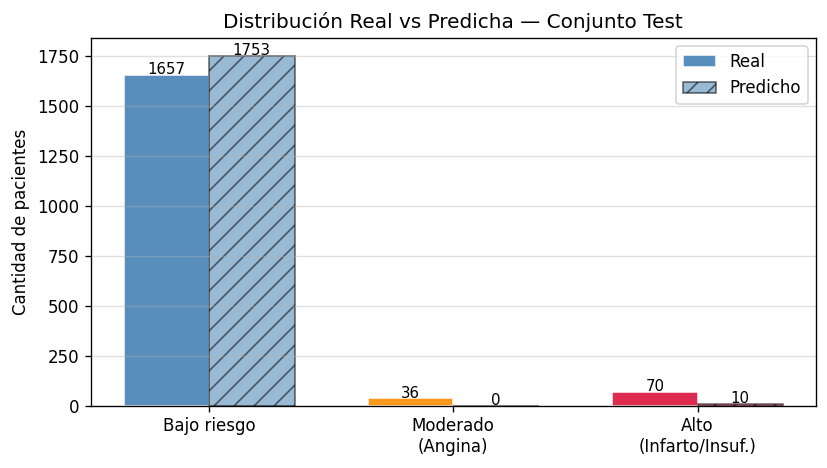

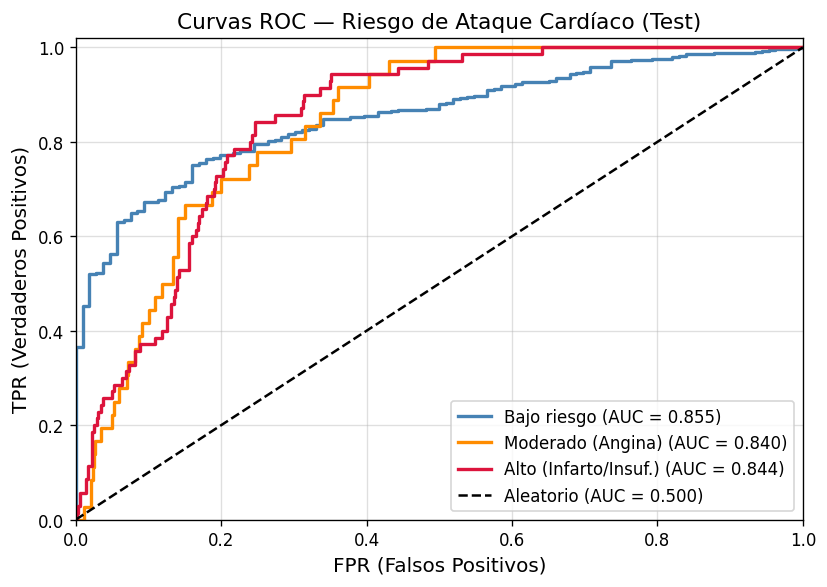


RESUMEN COMPARATIVO — Accuracy en Test
  Baseline (sin reg.)       acc_test = 0.9348
  L2 weight_decay=0.01      acc_test = 0.9376
  Early Stopping            acc_test = 0.9359
  Dropout + Early Stop      acc_test = 0.9370


In [43]:
from sklearn.metrics import roc_curve

# ── Distribución real vs predicha ─────────────────────────────────────────
real_counts  = pd.Series(y_test).value_counts().sort_index()
pred_counts  = pd.Series(y_pred).value_counts().sort_index().reindex([0,1,2], fill_value=0)

x     = np.arange(3)
width = 0.35
fig, ax = plt.subplots(figsize=(7, 4), dpi=120)
bars1 = ax.bar(x - width/2, real_counts, width, label='Real',
               color=colors_cls, edgecolor='white', alpha=0.9)
bars2 = ax.bar(x + width/2, pred_counts, width, label='Predicho',
               color=colors_cls, edgecolor='black', alpha=0.55, hatch='//')
ax.set_xticks(x)
ax.set_xticklabels(['Bajo riesgo', 'Moderado\n(Angina)', 'Alto\n(Infarto/Insuf.)'], fontsize=10)
ax.set_ylabel('Cantidad de pacientes')
ax.set_title('Distribución Real vs Predicha — Conjunto Test', fontsize=12)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.4)
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(int(bar.get_height())), ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(int(bar.get_height())), ha='center', fontsize=9)
plt.tight_layout()
plt.show()

# ── Curvas ROC multiclase ─────────────────────────────────────────────────
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

plt.figure(figsize=(7, 5), dpi=120)
for i, (cls, color) in enumerate(zip(classes, colors_cls)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    auc = roc_auc_score(y_test_bin[:, i], y_proba[:, i])
    plt.plot(fpr, tpr, color=color, linewidth=2,
             label=f"{cls} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label='Aleatorio (AUC = 0.500)')
plt.axis([0, 1, 0, 1.02])
plt.xlabel('FPR (Falsos Positivos)', fontsize=12)
plt.ylabel('TPR (Verdaderos Positivos)', fontsize=12)
plt.title('Curvas ROC — Riesgo de Ataque Cardíaco (Test)', fontsize=13)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

# ── Resumen final de todos los experimentos ───────────────────────────────
print("\n" + "=" * 55)
print("RESUMEN COMPARATIVO — Accuracy en Test")
print("=" * 55)

for nombre, modelo in [
    ("Baseline (sin reg.)", model_base),
    ("L2 weight_decay=0.01", model_l2),
    ("Early Stopping", model_es),
    ("Dropout + Early Stop",  model_dp)
]:
    modelo.eval()
    with torch.no_grad():
        p = torch.argmax(softmax(modelo(torch.from_numpy(X_test).float())), axis=1).numpy()
    print(f"  {nombre:<25} acc_test = {accuracy_score(y_test, p):.4f}")